In [ ]:
import networkx as nx

def generate_ws_graph(N: int, k: int, p: float, seed: int | None = None) -> nx.Graph:
    """
    Gera uma rede Small-World usando o modelo Watts–Strogatz.
    
    Parâmetros
    ----------
    N : int
        Número de nós.
    k : int
        Cada nó é inicialmente conectado a k vizinhos mais próximos em anel (precisa ser par).
    p : float
        Probabilidade de reconectar cada aresta (0 = regular, 1 = aleatória).
    seed : int | None
        Semente opcional para reprodutibilidade.
    """
    if k % 2 != 0:
        raise ValueError("k deve ser par no modelo Watts–Strogatz.")

    G = nx.watts_strogatz_graph(N, k, p, seed=seed)
    G.remove_edges_from(nx.selfloop_edges(G))
    return G


def save_graph_as_txt(G: nx.Graph, out_dir: str = "network-save", filename: str = "graph.txt") -> str:
    """
    Salva o grafo em formato edgelist (u v por linha) em out_dir/filename.
    """
    os.makedirs(out_dir, exist_ok=True)
    path = Path(out_dir) / filename
    nx.write_edgelist(G, path, data=False)
    return str(path)



G = generate_ws_graph(N=1000, k=4, p=0.0)
file_path = save_graph_as_txt(G, out_dir="network-save", filename="ws_graph.txt")

In [15]:
# -*- coding: utf-8 -*-
import os
import math
import time
import random
from pathlib import Path
import networkx as nx

# ============================================================
# 🔢 Mersenne Twister 64-bit (placeholder usando Python's random)
# ============================================================

NN = 312
mt = [0] * NN
mti = 0

def genrand64_int64():
    """
    Generate a pseudo-random 64-bit integer.

    Notes
    -----
    Placeholder using Python's built-in RNG.
    """
    return random.getrandbits(64)

def genrand64_real3():
    """
    Generate a random float in the interval [0, 1).
    """
    return genrand64_int64() / float(1 << 64)

def init_genrand64(seed: int):
    """
    Initialize placeholder state for MT19937-64 and sync Python RNG.
    """
    global mt, mti
    random.seed(seed)
    mt[0] = seed
    for mti in range(1, NN):
        mt[mti] = (6364136223846793005 * (mt[mti-1] ^ (mt[mti-1] >> 62)) + mti) & ((1 << 64) - 1)

def random_attack_node(N: int) -> int:
    """
    Select a random node uniformly from the set {1, ..., N}.
    """
    return int(genrand64_real3() * N) + 1

# ============================================================
# 🔧 Utilidades para BOND e centrais
# ============================================================

def bond_to_graph(bond, N):
    """
    Convert a 'bond' structure into a NetworkX graph (1-index -> 1-index).
    """
    G = nx.Graph()
    G.add_nodes_from(range(1, N + 1))
    for i in range(1, N + 1):
        for idx in range(1, bond[0][i] + 1):
            j = bond[i][idx]
            if i < j:
                G.add_edge(i, j)
    return G

def get_hub_nodes(N, bond, top_k=1):
    """
    Get the top-k hub nodes by degree.
    """
    degree_list = [(bond[0][i], i) for i in range(1, N + 1)]
    degree_list.sort(key=lambda x: x[0], reverse=True)
    return [i for _, i in degree_list[:top_k]]

def select_hub_node(N, bond, top_k=1):
    """
    Select one node among the top-k hubs (random tie-breaking).
    """
    hubs = get_hub_nodes(N, bond, top_k=top_k)
    return random.choice(hubs) if hubs else None

def get_closeness_nodes(N, bond, top_k=1):
    """
    Get the top-k nodes by closeness centrality.
    """
    G = bond_to_graph(bond, N)
    clos = nx.closeness_centrality(G)
    ordered = sorted(clos.items(), key=lambda kv: kv[1], reverse=True)
    return [n for n, _ in ordered[:top_k]]

def select_closeness_node(N, bond, top_k=1):
    """
    Select one node among the top-k by closeness centrality.
    """
    nodes = get_closeness_nodes(N, bond, top_k=top_k)
    return random.choice(nodes) if nodes else None

def get_betweenness_nodes(N, bond, top_k=1, normalized=True):
    """
    Get the top-k nodes by betweenness centrality.
    """
    G = bond_to_graph(bond, N)
    btw = nx.betweenness_centrality(G, normalized=normalized)
    ordered = sorted(btw.items(), key=lambda kv: kv[1], reverse=True)
    return [n for n, _ in ordered[:top_k]]

def select_betweenness_node(N, bond, top_k=1, normalized=True):
    """
    Select one node among the top-k by betweenness centrality.
    """
    nodes = get_betweenness_nodes(N, bond, top_k=top_k, normalized=normalized)
    return random.choice(nodes) if nodes else None

def find_node(i, j, bond):
    """
    Find the neighbor index of node j in the adjacency list of node i.
    Returns k (1..deg(i)) or -1 if not found.
    """
    for k in range(1, bond[0][i] + 1):
        if bond[i][k] == j:
            return k
    return -1

def copy_network(N, origin_bond, copy_bond):
    """
    Copy degrees and neighbor lists from one bond structure to another.
    """
    for i in range(1, N + 1):
        deg = origin_bond[0][i]
        copy_bond[0][i] = deg
        copy_bond[i] = origin_bond[i][:deg + 1]

# ============================================================
# 🌱 Geradores auxiliares (opcionais) e IO
# ============================================================

def generate_ba_graph(N: int, m: int, seed: int | None = None) -> nx.Graph:
    """
    Gera uma rede Barabási–Albert (scale-free) com N nós, anexando m arestas a cada novo nó.
    """
    G = nx.barabasi_albert_graph(N, m, seed=seed)
    G.remove_edges_from(nx.selfloop_edges(G))
    return G

def save_graph_as_txt(G: nx.Graph, out_dir: str = "network-save", filename: str = "graph.txt") -> str:
    """
    Salva o grafo em formato edgelist (u v por linha) em out_dir/filename.
    """
    os.makedirs(out_dir, exist_ok=True)
    path = Path(out_dir) / filename
    nx.write_edgelist(G, path, data=False)
    return str(path)

def read_network_from_txt(path, one_indexed=False):
    """
    Lê um arquivo .txt com arestas e retorna um grafo NetworkX.
    Formato esperado: cada linha contém 'i j'.
    """
    G = nx.Graph()
    with open(path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            i, j = map(int, parts[:2])
            if one_indexed:
                i, j = i - 1, j - 1
            G.add_edge(i, j)
    return G

def network_to_bond(G):
    """
    Converte grafo NetworkX para estrutura 'bond' (1-index, lista).
    bond[0][i] = grau do nó i ; bond[i] = [0, viz1, viz2, ...]
    Garante ids consecutivos 1..N.
    """
    nodes = sorted(G.nodes())
    id_map = {old: i+1 for i, old in enumerate(nodes)}
    N = len(nodes)

    bond = [None] * (N + 1)
    bond[0] = [0] * (N + 1)
    for i in range(1, N + 1):
        bond[i] = [0]

    for (u, v) in G.edges():
        i1 = id_map[u]
        j1 = id_map[v]
        bond[0][i1] += 1
        bond[0][j1] += 1
        bond[i1].append(j1)
        bond[j1].append(i1)

    return bond, N

# ============================================================
# 🔍 BFS / Amostragem de caminho mais curto
# ============================================================

def clean_time_stamp(update_time, E):
    """
    Reset all timestamps to zero (1..E).
    """
    for i in range(1, E+1):
        update_time[i] = 0

def simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp):
    """
    BFS até distância C, ou até alcançar o alvo (target).
    Retorna: 0 (explorou), 1 (atingiu C), 2 (alcançou target).
    """
    int_distance = 0
    control = 0
    vec[0] = 1
    vec[1] = source
    visited[source] = 0
    dag[0][source] = 0
    nr_sp[source] = 1
    reset[0] = 1
    reset[1] = source
    while vec[0] > 0 and control == 0:
        tmp_vec[0] = 0
        int_distance += 1
        if int_distance == C:
            control = 1
        for i in range(1, vec[0] + 1):
            n = vec[i]
            for j in range(1, bond[0][n] + 1):
                m = bond[n][j]
                if m == target:
                    control = 2
                if visited[m] < 0:
                    tmp_vec[0] += 1
                    tmp_vec[tmp_vec[0]] = m
                    visited[m] = visited[n] + 1
                    reset[0] += 1
                    reset[reset[0]] = m
                if visited[m] == int_distance:
                    dag[0][m] += 1
                    dag[m][dag[0][m]] = n
                    nr_sp[m] += nr_sp[n]
        for i2 in range(tmp_vec[0] + 1):
            vec[i2] = tmp_vec[i2]
    return control

def sample_random_path(C, N, dag, source, target, path, nr_sp):
    """
    Amostra um caminho mais curto do target ao source, usando o DAG de predecessores.
    """
    control = 0
    path[0] = 1
    path[1] = target
    while control == 0:
        n = path[path[0]]
        if dag[0][n] > 0:
            T = 0
            for i in range(1, dag[0][n] + 1):
                T += nr_sp[dag[n][i]]
            q = int(genrand64_real3() * T) + 1
            if q > T:
                q = 1
            i = 0
            acc = 0
            found = 0
            while found == 0:
                i += 1
                acc += nr_sp[dag[n][i]]
                if q <= acc:
                    found = dag[n][i]
            path[0] += 1
            path[path[0]] = found
            if path[0] == C + 1 or path[path[0]] == source:
                control = 1
        else:
            path[0] = 0
            return

def get_path_of_pair(source, target, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp):
    """
    Computa e amostra um caminho mais curto entre (source, target), limitado por C.
    Retorna o comprimento (path[0]) ou 0 se não existir.
    """
    control = simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp)
    path[0] = 0
    if control == 2:
        sample_random_path(C, N, dag, source, target, path, nr_sp)
    for i in range(1, reset[0] + 1):
        node = reset[i]
        visited[node] = -1
        dag[0][node] = 0
        nr_sp[node] = 0
    return path[0]

# ============================================================
# 🎲 Outras rotinas auxiliares
# ============================================================

def geometric_distribution(P: float) -> int:
    """
    Amostra de distribuição geométrica com parâmetro P.
    Retorna k ≥ 1 com prob (1-P)^(k-1) * P; -1 se P <= 0.
    """
    if P <= 0:
        return -1
    if P == 1:
        return 1
    u = genrand64_real3()
    return int(1 + math.floor(math.log(u) / math.log(1. - P)))

def adjust_pair(pairs, q):
    """
    Move o par na posição q para o final da lista ativa e decrementa contador.
    """
    node1 = pairs[0][q]
    node2 = pairs[1][q]
    pairs[0][q] = pairs[0][pairs[0][0]]
    pairs[1][q] = pairs[1][pairs[0][0]]
    pairs[0][pairs[0][0]] = node1
    pairs[1][pairs[0][0]] = node2
    pairs[0][0] -= 1

# ============================================================
# 🎯 Seleção de nós (NOVO: modo + rank)
# ============================================================

def _ordered_by_degree(nodes, bond):
    return sorted(nodes, key=lambda i: bond[0][i], reverse=True)

def _ordered_by_centrality(nodes, bond, N, kind="closeness"):
    G = bond_to_graph(bond, N)
    if kind == "closeness":
        cent = nx.closeness_centrality(G)
    elif kind == "betweenness":
        cent = nx.betweenness_centrality(G, normalized=True)
    else:
        raise ValueError("centrality kind must be 'closeness' or 'betweenness'")
    return sorted(nodes, key=lambda i: cent[i], reverse=True)

def select_node(N, bond, mode="random", rank=1, exclude=None):
    """
    Seleciona um nó conforme o modo e o rank.
    mode: 'random' | 'hub' | 'closeness' | 'betweenness'
    rank: 1 (maior), 2 (2º maior), etc.
    exclude: nó a ser evitado (ex.: o já escolhido).
    """
    nodes = list(range(1, N+1))
    if exclude is not None and exclude in nodes:
        nodes.remove(exclude)
    if not nodes:
        return None

    if mode == "random":
        return random.choice(nodes)

    if mode == "hub":
        ordered = _ordered_by_degree(nodes, bond)
    elif mode == "closeness":
        ordered = _ordered_by_centrality(nodes, bond, N, kind="closeness")
    elif mode == "betweenness":
        ordered = _ordered_by_centrality(nodes, bond, N, kind="betweenness")
    else:
        raise ValueError(f"[ERRO] Modo de ataque desconhecido: {mode}")

    idx = min(max(1, rank) - 1, len(ordered) - 1)
    return ordered[idx]

# ============================================================
# 🧨 Núcleo dos ataques (versão antiga — mantida p/ compatibilidade)
# ============================================================

def _core_pair_removal_loop(C, N, bond, edges, E, update_time, threshold, source_selector):
    """
    Rotina central para ataques por remoção de pares ao longo de caminhos mais curtos.
    (VERSÃO ANTIGA — MANTIDA)
    """
    path = [0] * (N+1)
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)

    dag = []
    dag.append([0] * (N+1))
    for i in range(1, N+1):
        dag.append([0] * (bond[0][i] + 1))
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    count_E = 0
    tau = 1
    num_failures = 0

    while num_failures < threshold:
        n = source_selector()
        if n is None:
            edges[0][0] = 0
            return
        m = random_attack_node(N)
        while m == n:
            m = random_attack_node(N)

        if bond[0][n] > bond[0][m]:
            n, m = m, n

        if C == -1:
            p = get_path_of_pair(n, m, N, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)
        else:
            p = get_path_of_pair(n, m, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)

        if p > 0:
            num_failures = 0
            for j in range(1, path[0]):
                s = path[j]
                t = path[j+1]

                v1 = find_node(s, t, bond)
                bond[s][v1] = bond[s][bond[0][s]]
                bond[0][s] -= 1

                v2 = find_node(t, s, bond)
                bond[t][v2] = bond[t][bond[0][t]]
                bond[0][t] -= 1

                count_E += 1
                if s < t:
                    edges[0][count_E] = s
                    edges[1][count_E] = t
                else:
                    edges[0][count_E] = t
                    edges[1][count_E] = s
                update_time[count_E] += tau
        else:
            num_failures += 1

        tau += 1

    for i in range(count_E + 1, E + 1):
        update_time[i] += tau

    edges[0][0] = count_E

# ============================================================
# 🧨 Núcleo dos ataques (NOVA VERSÃO: dois modos + ranks)
# ============================================================

def _core_pair_removal_loop_v3(C, N, bond, edges, E, update_time, threshold,
                               attack_mode_1="random", attack_mode_2="random",
                               rank_1=1, rank_2=1):
    """
    Rotina central para ataques por remoção de pares ao longo de caminhos mais curtos.
    Agora com DOIS modos de seleção (attack_mode_1, attack_mode_2) e ranks (rank_1, rank_2).
    Ex.: hub(rank=1) x hub(rank=2); closeness x random; betweenness(2) x betweenness(3), etc.
    """
    path = [0] * (N+1)
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)

    dag = []
    dag.append([0] * (N+1))
    for i in range(1, N+1):
        dag.append([0] * (bond[0][i] + 1))
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    count_E = 0
    tau = 1
    num_failures = 0

    while num_failures < threshold:
        n = select_node(N, bond, mode=attack_mode_1, rank=rank_1, exclude=None)
        if n is None:
            edges[0][0] = 0
            return

        m = select_node(N, bond, mode=attack_mode_2, rank=rank_2, exclude=n)
        if m is None:
            edges[0][0] = 0
            return

        # Ordenação padrão (mantém a convenção original)
        if bond[0][n] > bond[0][m]:
            n, m = m, n

        # Caminho mais curto (limitado por C; C=-1 => usa N)
        if C == -1:
            p = get_path_of_pair(n, m, N, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)
        else:
            p = get_path_of_pair(n, m, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)

        if p > 0:
            num_failures = 0
            for j in range(1, path[0]):
                s = path[j]
                t = path[j+1]

                v1 = find_node(s, t, bond)
                bond[s][v1] = bond[s][bond[0][s]]
                bond[0][s] -= 1

                v2 = find_node(t, s, bond)
                bond[t][v2] = bond[t][bond[0][t]]
                bond[0][t] -= 1

                count_E += 1
                if s < t:
                    edges[0][count_E] = s
                    edges[1][count_E] = t
                else:
                    edges[0][count_E] = t
                    edges[1][count_E] = s
                update_time[count_E] += tau
        else:
            num_failures += 1

        tau += 1

    for i in range(count_E + 1, E + 1):
        update_time[i] += tau

    edges[0][0] = count_E

# ============================================================
# 🧨 Wrappers antigos (mantidos)
# ============================================================

def remove_pair_wo_pair_info_v2(C, N, bond, edges, E, update_time, threshold):
    """
    Ataque aleatório: n e m escolhidos uniformemente.
    """
    _core_pair_removal_loop(
        C, N, bond, edges, E, update_time, threshold,
        source_selector=lambda: random_attack_node(N)
    )

def remove_pair_wo_pair_info_v2_hubs(C, N, bond, edges, E, update_time, threshold, top_k=1):
    """
    Ataque por hubs: n entre os top-k graus.
    """
    _core_pair_removal_loop(
        C, N, bond, edges, E, update_time, threshold,
        source_selector=lambda: select_hub_node(N, bond, top_k=top_k)
    )

def remove_pair_wo_pair_info_v2_closeness(C, N, bond, edges, E, update_time, threshold, top_k=1):
    """
    Ataque por closeness: n entre os top-k closeness.
    """
    _core_pair_removal_loop(
        C, N, bond, edges, E, update_time, threshold,
        source_selector=lambda: select_closeness_node(N, bond, top_k=top_k)
    )

def remove_pair_wo_pair_info_v2_betweenness(C, N, bond, edges, E, update_time, threshold, top_k=1):
    """
    Ataque por betweenness: n entre os top-k betweenness.
    """
    _core_pair_removal_loop(
        C, N, bond, edges, E, update_time, threshold,
        source_selector=lambda: select_betweenness_node(N, bond, top_k=top_k, normalized=True)
    )

# ============================================================
# 🧮 Ataque com pares pré-computados
# ============================================================

def remove_pair_w_pair_info_v2(C, N, bond, pairs, edges, update_time):
    """
    Remove arestas seguindo caminhos mais curtos entre pares pré-computados.
    """
    path = [0] * (N+1)
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)

    dag = []
    for i in range(N+1):
        dag.append([0] * (N+1 if i == 0 else (bond[0][i] + 1)))

    for i in range(1, N+1):
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    interval = 0
    E = edges[0][0]

    while pairs[0][0] > 0:
        num_pairs = pairs[0][0]
        link_prob = 2.0 * float(num_pairs) / (float(N) * float(N - 1))
        interval += geometric_distribution(link_prob)

        q = int(genrand64_real3() * num_pairs + 1)
        n = pairs[0][q]
        m = pairs[1][q]

        source = n
        target = m
        if bond[0][source] > bond[0][target]:
            n, m = m, n

        if C == -1:
            p = get_path_of_pair(n, m, N, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)
        else:
            p = get_path_of_pair(n, m, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)

        if p > 0:
            for j in range(1, path[0]):
                s = path[j]
                t = path[j+1]

                v = find_node(s, t, bond)
                bond[s][v] = bond[s][bond[0][s]]
                bond[0][s] -= 1

                v = find_node(t, s, bond)
                bond[t][v] = bond[t][bond[0][t]]
                bond[0][t] -= 1

                E += 1
                if s < t:
                    edges[0][E] = s
                    edges[1][E] = t
                else:
                    edges[0][E] = t
                    edges[1][E] = s
                update_time[E] += interval

            control = simple_bfs(C, N, bond, n, m, vec, tmp_vec, visited, reset, dag, nr_sp)
            if control == 1:
                adjust_pair(pairs, q)
        else:
            adjust_pair(pairs, q)

        for i2 in range(1, reset[0] + 1):
            node = reset[i2]
            visited[node] = -1
            dag[0][node] = 0
            nr_sp[node] = 0

    edges[0][0] = E

def find_all_possible_pairs(C, N, bond, pairs):
    """
    Encontra todos os pares conectados por caminhos ≤ C (ou todos se C == -1).
    """
    num_pairs = 0
    dag = []
    list_pairs = []
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)

    dag.append([0] * (N+1))
    for i in range(1, N+1):
        dag.append([0] * (bond[0][i] + 1))

    list_pairs.append([0] * (N+1))
    for i in range(1, N+1):
        list_pairs.append([0])

    for i in range(1, N+1):
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    target = -1
    for source in range(1, N+1):
        _ = simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp)
        for k in range(1, reset[0] + 1):
            n = reset[k]
            if source < n and find_node(source, n, list_pairs) < 0:
                list_pairs[0][source] += 1
                list_pairs[source].append(n)
                num_pairs += 1
        for k in range(1, reset[0] + 1):
            node = reset[k]
            visited[node] = -1
            dag[0][node] = 0
            nr_sp[node] = 0

    while len(pairs[0]) < num_pairs + 1:
        pairs[0].append(0)
    while len(pairs[1]) < num_pairs + 1:
        pairs[1].append(0)

    num_pairs = 0
    for i in range(1, N+1):
        for j in range(1, list_pairs[0][i] + 1):
            num_pairs += 1
            pairs[0][num_pairs] = i
            pairs[1][num_pairs] = list_pairs[i][j]

    pairs[0][0] = num_pairs
    return num_pairs

# ============================================================
# 🌳 Reconstrução de componentes (NZ modificado)
# ============================================================

def tree_find_root(n, root, res):
    """
    Union-find: encontra raiz de n (com compressão de caminhos).
    """
    if root[0][n] == n:
        res[0] = root[0][n]
        res[1] = root[1][n]
        return
    tree_find_root(root[0][n], root, res)

def modified_NZ_algorithm(N, edges, largest_cluster):
    """
    Reconstrói clusters a partir da ordem de remoção e calcula métricas da maior componente.
    """
    root = [[0]*(N+1), [0]*(N+1)]
    res = [0, 0]
    larg = 1
    av2 = float(N - 1)

    for i in range(1, N+1):
        root[0][i] = i
        root[1][i] = 1

    E = edges[0][0]
    for e in range(E, 0, -1):
        n = edges[0][e]
        m = edges[1][e]
        av2 += float(larg) * float(larg)

        tree_find_root(n, root, res)
        rn, sn = res[0], res[1]
        tree_find_root(m, root, res)
        rm, sm = res[0], res[1]

        if rn != rm:
            av2 -= float(sn) * float(sn)
            av2 -= float(sm) * float(sm)
            if sn > sm:
                root[0][rm] = rn
                root[1][rm] = 1
                root[1][rn] = sn + sm
            else:
                root[0][rn] = rm
                root[1][rn] = 1
                root[1][rm] = sn + sm
            if sn + sm > larg:
                larg = sn + sm

        tmp = float(larg) / float(N)
        largest_cluster[1][e] = tmp
        largest_cluster[2][e] = tmp * tmp
        largest_cluster[3][e] = tmp * tmp * tmp
        largest_cluster[4][e] = tmp * tmp * tmp * tmp

        av = float(N) - float(larg)
        if rn != rm:
            av2 += float(sn + sm) * float(sn + sm)
        av2 -= float(larg) * float(larg)

        if av > 0:
            largest_cluster[5][e] = av2 / av

# ============================================================
# 🧭 Orquestração do ataque + pós-processamento
# ============================================================

def efficient_pair_removal(C, N, bond, edges, E, update_time, threshold,
                           hub_mode=False, closeness_mode=False, betweenness_mode=False, top_k=1,
                           # ↓↓↓ NOVOS PARÂMETROS (opcionais, não quebram compat.)
                           attack_mode_1=None, attack_mode_2="random",
                           rank_1=1, rank_2=1):
    """
    Seleciona e executa a estratégia de ataque, depois roda o pipeline com pares.

    Compatibilidade:
    - Se attack_mode_1 is None, usa os flags antigos (betweenness_mode/closeness_mode/hub_mode/random).
    - Caso contrário, usa a versão nova com (attack_mode_1, rank_1) e (attack_mode_2, rank_2).
    """
    if attack_mode_1 is None:
        # CAMINHO ANTIGO (mantido)
        if betweenness_mode:
            remove_pair_wo_pair_info_v2_betweenness(C, N, bond, edges, E, update_time, threshold, top_k=top_k)
        elif closeness_mode:
            remove_pair_wo_pair_info_v2_closeness(C, N, bond, edges, E, update_time, threshold, top_k=top_k)
        elif hub_mode:
            remove_pair_wo_pair_info_v2_hubs(C, N, bond, edges, E, update_time, threshold, top_k=top_k)
        else:
            remove_pair_wo_pair_info_v2(C, N, bond, edges, E, update_time, threshold)
    else:
        # NOVO CAMINHO (dois modos + ranks)
        _core_pair_removal_loop_v3(
            C, N, bond, edges, E, update_time, threshold,
            attack_mode_1=attack_mode_1,
            attack_mode_2=attack_mode_2,
            rank_1=rank_1,
            rank_2=rank_2
        )

    # Subsequent pipeline
    pairs = [[0], [0]]
    find_all_possible_pairs(C, N, bond, pairs)
    remove_pair_w_pair_info_v2(C, N, bond, pairs, edges, update_time)

# ============================================================
# 🚀 MAIN (ajustado para ler TXT e montar bond)
# ============================================================

def main(N_values=[300, 500, 600, 1000],
         C_values=None,
         num_iter=1000,
         num_instance=1,
         hub_mode=False,
         closeness_mode=False,
         betweenness_mode=False,
         top_k=1,
         output_dir="./data",
         input_txt=None,
         one_indexed=True,
         # ↓↓↓ NOVOS PARÂMETROS (opcionais, não quebram compat.)
         attack_mode_1=None, attack_mode_2="random",
         rank_1=1, rank_2=1):
    """
    Executa SPP para múltiplos N e C. Se input_txt for fornecido, lê a rede do arquivo.

    Novos parâmetros:
    - attack_mode_1: 'random' | 'hub' | 'closeness' | 'betweenness' | None (usa flags antigos)
    - attack_mode_2: idem (p/ o segundo nó)
    - rank_1, rank_2: 1 (maior), 2 (2º maior), etc. Aplicável a 'hub', 'closeness', 'betweenness'.
    """
    start = time.time()

    # Semente RNG
    pid_id = int(time.time()) * os.getpid()
    init_genrand64(pid_id)

    # Se houver arquivo TXT, a rede vem do arquivo (N será obtido do grafo)
    if input_txt is not None:
        # Ler TXT e montar bond uma única vez
        G = read_network_from_txt(input_txt, one_indexed=one_indexed)
        bond_base, N_file = network_to_bond(G)
        N_values = [N_file]  # força N a ser o do arquivo

    for N in N_values:
        # C_list
        if C_values is None:
            C_list = [1, 2, 3, N]
        else:
            C_list = [c if c != "N" else N for c in C_values]

        for C in C_list:
            print(f"Starting simulation: N={N}, C={C}, "
                  f"hub={hub_mode}, closeness={closeness_mode}, betweenness={betweenness_mode}, "
                  f"attack_mode_1={attack_mode_1}, attack_mode_2={attack_mode_2}, "
                  f"rank_1={rank_1}, rank_2={rank_2}")

            for _ in range(num_instance):
                # Montar bond de base (de TXT) ou rede vazia (se futuramente quiser usar geradores)
                if input_txt is not None:
                    # copia profunda da base para esta instância
                    bond = [[] for _ in range(N + 1)]
                    bond[0] = [0] * (N + 1)
                    for i in range(1, N + 1):
                        bond[i] = [0]
                    copy_network(N, bond_base, bond)
                else:
                    # Caso não haja TXT, aqui você poderia gerar com ER/BA/Waxman
                    # Por ora, deixamos rede vazia → usuário deve fornecer input_txt
                    raise ValueError("Sem 'input_txt'. Forneça um arquivo .txt com a rede (lista de arestas).")

                # Tamanho e estruturas
                E = int(sum(bond[0][i] for i in range(1, N+1)) // 2)
                edges = [[0] * (E+1), [0] * (E+1)]
                update_time = [0] * (E+1)
                largest_cluster = [[0.0] * (E+1) for _ in range(6)]

                for iteration in range(num_iter):
                    # prepara uma cópia para atacar
                    copy_bond = [[] for _ in range(N+1)]
                    copy_bond[0] = [0] * (N+1)
                    copy_network(N, bond, copy_bond)

                    clean_time_stamp(update_time, E)
                    threshold = int(7 * (N**0.44))

                    # Executa estratégia (compatível ou nova)
                    efficient_pair_removal(
                        C, N, copy_bond, edges, E, update_time, threshold,
                        hub_mode=hub_mode,
                        closeness_mode=closeness_mode,
                        betweenness_mode=betweenness_mode,
                        top_k=top_k,
                        attack_mode_1=attack_mode_1,
                        attack_mode_2=attack_mode_2,
                        rank_1=rank_1,
                        rank_2=rank_2
                    )

                    # Maior componente
                    modified_NZ_algorithm(N, edges, largest_cluster)

                    # Salvar CSV
                    # Se estiver usando a API NOVA, reflete os dois modos e ranks
                    if attack_mode_1 is not None:
                        mode_name = f"{attack_mode_1}{rank_1}-{attack_mode_2}{rank_2}"
                    else:
                        mode_name = ("betweenness_attack" if betweenness_mode else
                                     "closeness_attack" if closeness_mode else
                                     "hub_attack" if hub_mode else "random")
                    C_folder = C if C > 0 else N
                    dir_path = f"{output_dir}/N{N}/{mode_name}/C{C_folder}/"
                    os.makedirs(dir_path, exist_ok=True)

                    file_name = f"{dir_path}full_data_{iteration}.csv"
                    with open(file_name, "w") as f:
                        for j in range(1, edges[0][0] + 1):
                            removed_edges = float(j) / float(edges[0][0])
                            f.write(
                                f"{removed_edges:.10f} "
                                f"{largest_cluster[1][j]:.10f} "
                                f"{largest_cluster[2][j]:.10f} "
                                f"{largest_cluster[3][j]:.10f} "
                                f"{largest_cluster[4][j]:.10f} "
                                f"{largest_cluster[5][j]:.10f} "
                                f"{edges[0][j]} "
                                f"{edges[1][j]} "
                                f"{update_time[j]}\n"
                            )
            print(f"Finished simulation: N={N}, C={C}\n")

    end = time.time()
    print(f"Total time: {end - start:.2f} seconds")


In [16]:
main(input_txt="./network-save/ws_graph.txt", num_iter=1,
     attack_mode_1="closeness", attack_mode_2="closeness",
     rank_1=1, rank_2=1)


Starting simulation: N=1000, C=1, hub=False, closeness=False, betweenness=False, attack_mode_1=closeness, attack_mode_2=closeness, rank_1=1, rank_2=1
Finished simulation: N=1000, C=1

Starting simulation: N=1000, C=2, hub=False, closeness=False, betweenness=False, attack_mode_1=closeness, attack_mode_2=closeness, rank_1=1, rank_2=1
Finished simulation: N=1000, C=2

Starting simulation: N=1000, C=3, hub=False, closeness=False, betweenness=False, attack_mode_1=closeness, attack_mode_2=closeness, rank_1=1, rank_2=1
Finished simulation: N=1000, C=3

Starting simulation: N=1000, C=1000, hub=False, closeness=False, betweenness=False, attack_mode_1=closeness, attack_mode_2=closeness, rank_1=1, rank_2=1
Finished simulation: N=1000, C=1000

Total time: 2567.13 seconds


In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ============================================================
# 🎨 Estilo
# ============================================================
def set_cm_text_style(prefer_tex=True):
    if prefer_tex:
        plt.rcParams.update({
            "text.usetex": True,
            "font.family": "serif",
            "font.serif": ["Computer Modern Roman"],
            "axes.unicode_minus": False,
            "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}",
        })
    else:
        plt.rcParams.update({
            "text.usetex": False,
            "font.family": "serif",
            "font.serif": ["DejaVu Serif"],
            "mathtext.fontset": "cm",
            "mathtext.rm": "serif",
            "mathtext.it": "serif:italic",
            "mathtext.bf": "serif:bold",
            "axes.unicode_minus": False,
        })

# ============================================================
# 📂 Carregar CSVs de uma configuração
# ============================================================
def load_simulation_data(N, C, attack_mode="hub1-hub1", drop_node=True):
    """
    Carrega todos os CSVs de uma configuração (N, C, modo ataque),
    empilha em um DataFrame e retorna lista de DFs.
    """
    data_dir = f'./data/N{N}/{attack_mode}/C{C}/'
    dfs = []

    if not os.path.exists(data_dir):
        print(f"[AVISO] Diretório não encontrado: {data_dir}")
        return []

    for file_name in os.listdir(data_dir):
        if not file_name.endswith(".csv"):
            continue
        df = pd.read_csv(
            os.path.join(data_dir, file_name),
            sep=r"\s+",
            header=None,
            names=["p", "m1", "m2", "m3", "m4", "s", "node1", "node2", "t"],
            engine="python",
        )
        if drop_node:
            df.drop(['node1', 'node2'], axis=1, inplace=True)
        dfs.append(df)

    return dfs

def compute_average_curves(N, C, attack_mode="random"):
    """
    Empilha todos os CSVs da configuração e retorna
    curva média + desvio padrão agrupada por p.
    """
    dfs = load_simulation_data(N, C, attack_mode=attack_mode)
    if not dfs:
        return pd.DataFrame()

    combined_df = pd.concat(dfs, ignore_index=True)
    mean_df = combined_df.groupby("p", as_index=False).mean(numeric_only=True)
    std_df  = combined_df.groupby("p", as_index=False).std(numeric_only=True)
    final_df = pd.merge(mean_df, std_df, on="p", suffixes=("", "_std"))
    return final_df

# ============================================================
# 📊 Gráfico único para N fixo com todas curvas de C
# ============================================================
def plot_m1_single_N_all_C_means(N, attack_mode="hub1-hub1", prefer_tex=True, fill_std=True):
    """
    Plota em um único gráfico as curvas médias de m1 para C=1,2,3,N.
    """
    set_cm_text_style(prefer_tex=prefer_tex)

    fig, ax = plt.subplots(figsize=(8.5, 6.2))
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    C_values = [1, 2, 3, N]
    labels = {1: r"$C=1$", 2: r"$C=2$", 3: r"$C=3$", N: r"$C=N$"}
    markers = ["o", "s", "D", "^"]

    any_plotted = False
    for idx, C in enumerate(C_values):
        df = compute_average_curves(N, C, attack_mode=attack_mode)
        if df.empty or "p" not in df or "m1" not in df:
            print(f"[AVISO] Sem dados para N={N}, C={C}, mode={attack_mode}.")
            continue

        ax.plot(
            df["p"], df["m1"],
            marker=markers[idx % len(markers)], linewidth=2.2, markersize=3.5,
            label=labels[C]
        )

        if fill_std and "m1_std" in df.columns and not df["m1_std"].isna().all():
            m = df["m1"].to_numpy()
            s = df["m1_std"].fillna(0).to_numpy()
            ax.fill_between(df["p"], m - s, m + s, alpha=0.18, linewidth=0)

        any_plotted = True

    if not any_plotted:
        print("[ERRO] Nenhuma curva foi plotada (dados ausentes).")
        return

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(r"$p$", fontsize=18)
    ax.set_ylabel(r"$N_{G}/N$", fontsize=18)
    ax.tick_params(labelsize=14, direction='in')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: '' if v == 0 else f'{v:g}'))

    ax.legend(fontsize=13, frameon=True, fancybox=True, edgecolor='black', loc='best')
    ax.set_title(rf"$N={N}$ — {attack_mode}", fontsize=14)

    fig.tight_layout()
    out = f"attack_{attack_mode}_N{N}_means.png"
    fig.savefig(out, dpi=300, bbox_inches='tight', transparent=True)
    print(f"[OK] Figura salva em: {out}")
    plt.show()


[OK] Figura salva em: attack_closeness1-closeness1_N1000_means.png


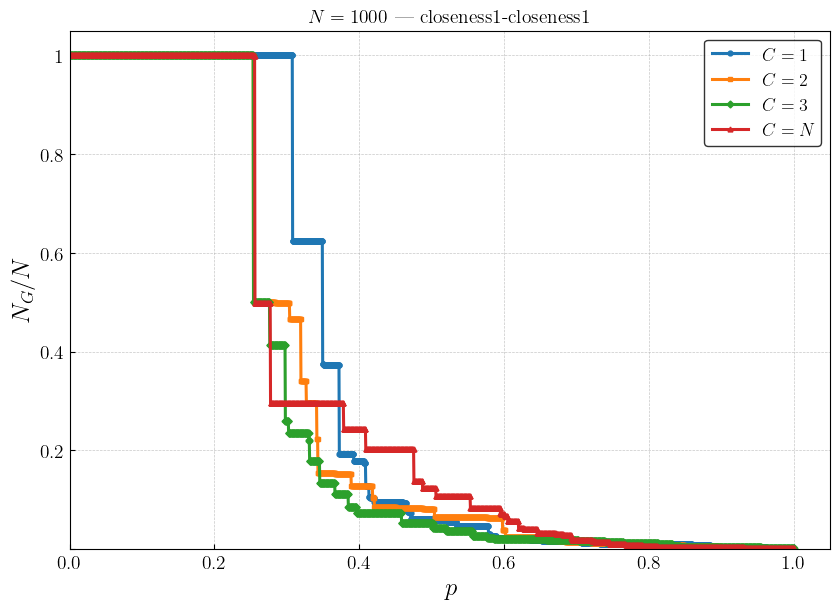

In [18]:
plot_m1_single_N_all_C_means(N=1000, attack_mode="closeness1-closeness1", prefer_tex=True, fill_std=True)

[OK] Figura salva em: attack_closeness1-closeness1_N1000_means.png


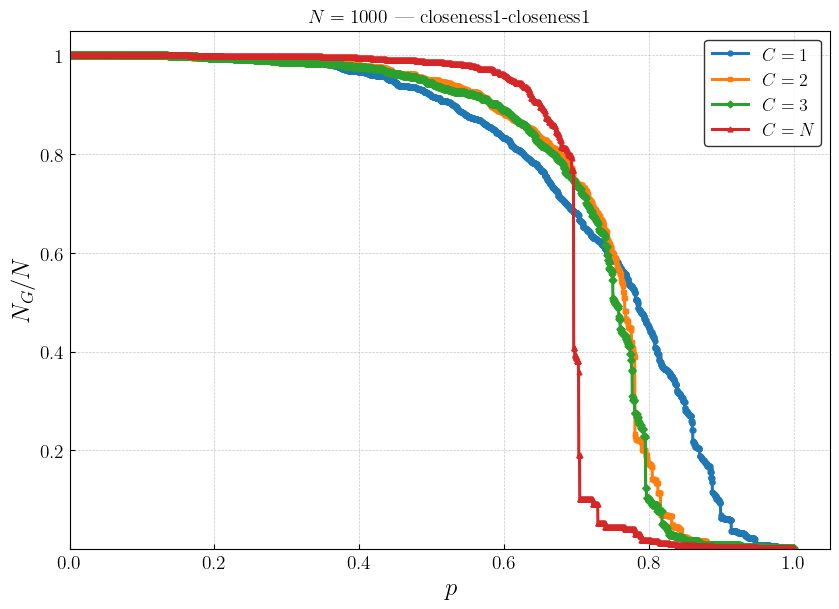

In [12]:
plot_m1_single_N_all_C_means(N=1000, attack_mode="closeness1-closeness1", prefer_tex=True, fill_std=True)

[OK] Figura salva em: attack_random1-random1_N5000_means.png


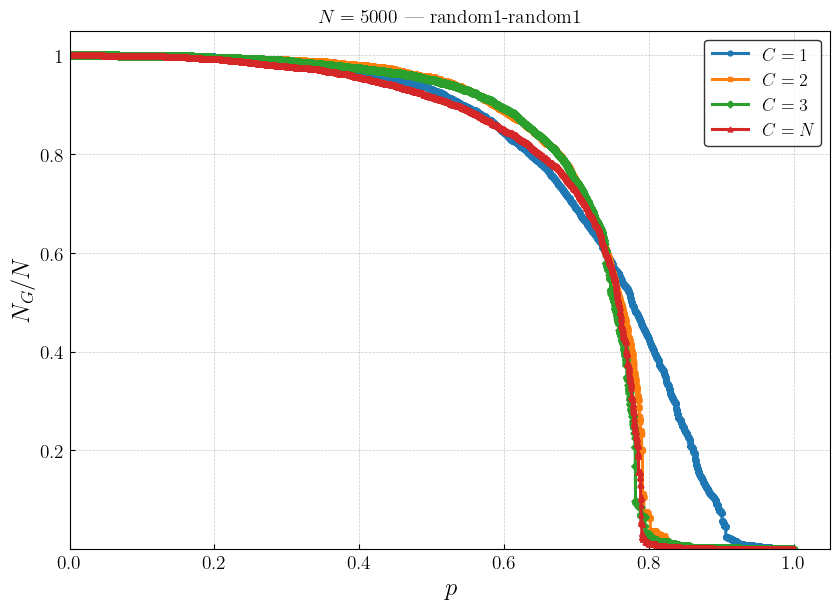

In [10]:
plot_m1_single_N_all_C_means(N=5000, attack_mode="random1-random1", prefer_tex=True, fill_std=True)

[OK] Figura salva em: attack_hub1-hub1_N1000_means.png


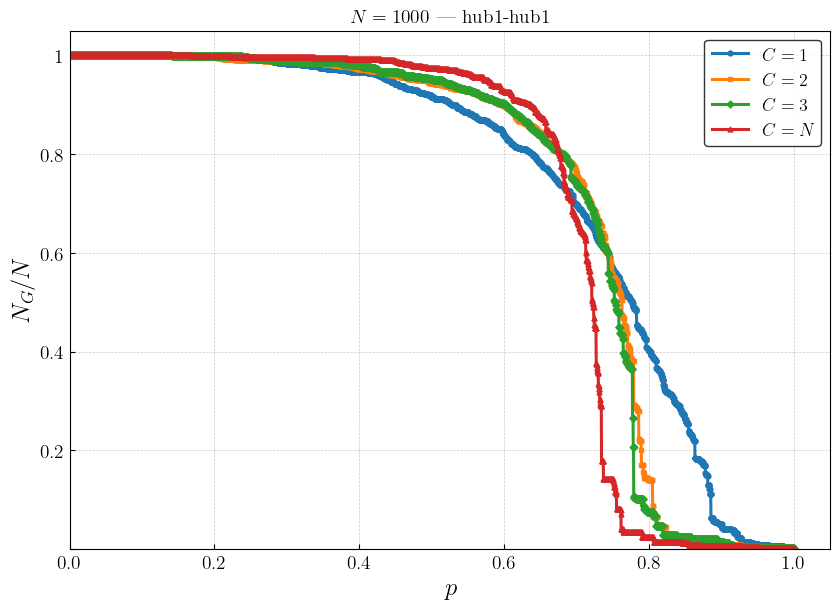

In [ ]:
plot_m1_single_N_all_C_means(N=1000, attack_mode="hub1-hub1", prefer_tex=True, fill_std=True)


[OK] Figura salva em: attack_hub1-hub1_N5000_means.png


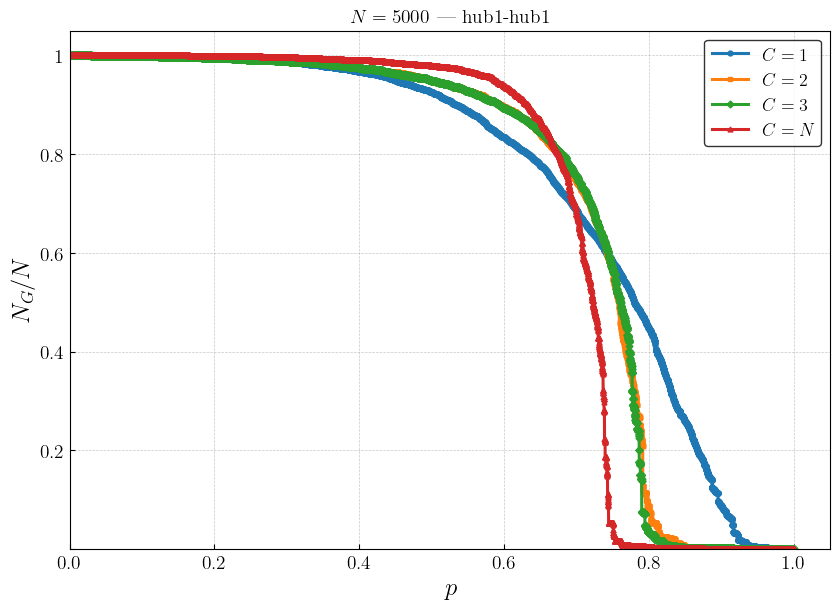

In [7]:
plot_m1_single_N_all_C_means(N=5000, attack_mode="hub1-hub1", prefer_tex=True, fill_std=True)
